***SALES PREDICTION USING PYTHON***

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\Acer\Downloads\advertising.csv")
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
df.shape

(200, 4)

In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000



**Basic Observation**

---
> Avg expense spend is highest on TV


> Avg expense spend is lowest on Radio


> Max sale is 27 and min is 1.6


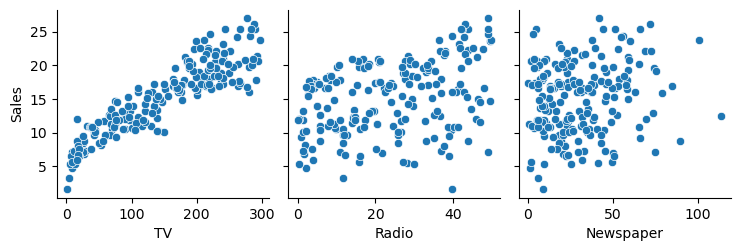

In [7]:
sns.pairplot(df, x_vars=['TV', 'Radio','Newspaper'], y_vars='Sales', kind='scatter')
plt.show()


**Pair Plot Observation**

---
TV vs Sales:
There's a strong linear relationship: as spending on TV increases, sales increase.

Radio vs Sales:
The relationship is weaker.
Still some positive trend, but more scattered than TV.

Newspaper vs Sales:
Appears random and highly scattered.
No clear pattern


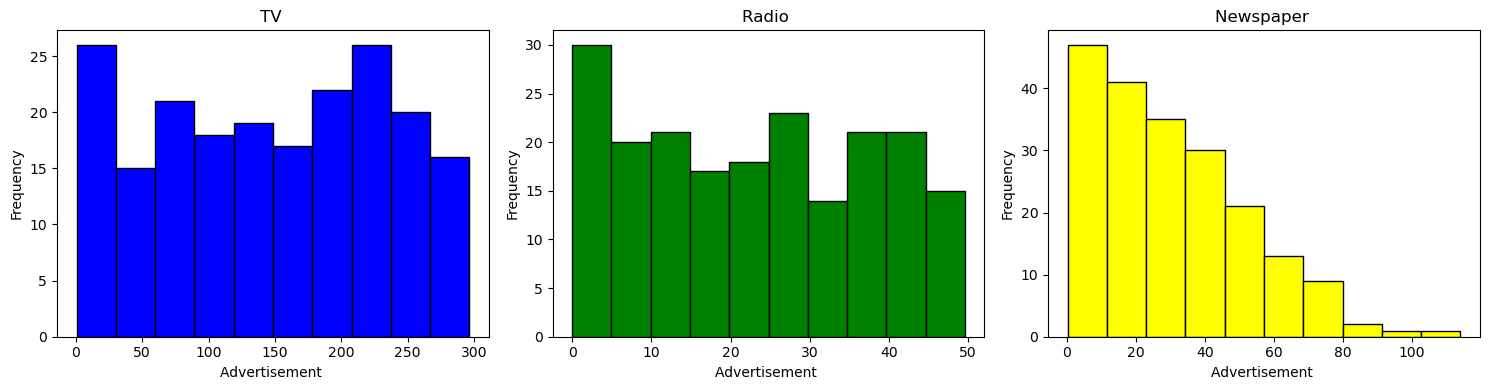

In [12]:
plt.figure(figsize=(15, 4))

# TV
plt.subplot(1, 3, 1)
df['TV'].plot.hist(bins=10, color='blue', edgecolor='black')
plt.title('TV ')
plt.xlabel('Advertisement ')
plt.ylabel('Frequency')

# Radio
plt.subplot(1, 3, 2)
df['Radio'].plot.hist(bins=10, color='green', edgecolor='black')
plt.title('Radio ')
plt.xlabel('Advertisement ')

#News Papers
plt.subplot(1, 3, 3)
df['Newspaper'].plot.hist(bins=10, color='yellow', edgecolor='black')
plt.title('Newspaper ')
plt.xlabel('Advertisement ')

plt.tight_layout()
plt.show()


**Histogram Observation**

---

*Most values are concentrated at lower ranges in radio*

*The majority sales is the result of low advertising cost in newspaper*

**WE CAN SEE SALES ARE HIGHLY COORELATED WITH THE TV**

**Model Training**

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

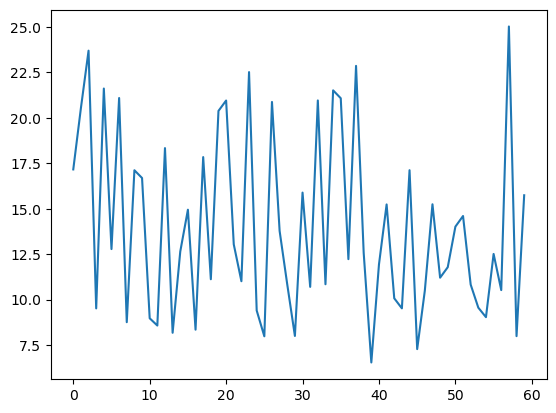

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
plt.plot(y_pred)

**Evaluation**

In [21]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [22]:
print(f"Mean Squared Error: {mse:.3f}")
print(f"R² Score: {r2:.3f}")

Mean Squared Error: 2.542
R² Score: 0.909


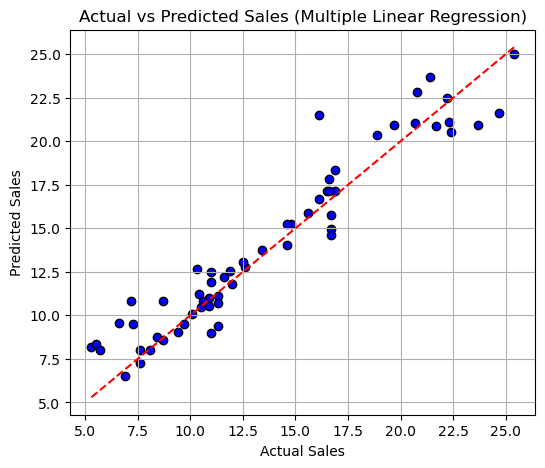

In [24]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales (Multiple Linear Regression)')
plt.grid(True)
plt.show()


**Interpretations**

The points are closely clustered around the red dashed line.

This means the model’s predictions are quite accurate and follow the actual sales closely.

The model captures the linear relationship between advertising spend and sales effectively.